In [13]:
using DataFrames,PythonPlot,StatsBase,Random,Distributions,CSV,DSP,NLsolve
PythonPlot.svg(true)
include("model.jl")
include("formulas.jl")
FIG_PATH = "/Users/elevien/Dartmouth College Dropbox/Ethan Levien/RESEARCH/ACTIVE/cell_size/cell_cycle_growth"

"/Users/elevien/Dartmouth College Dropbox/Ethan Levien/RESEARCH/ACTIVE/cell_size/cell_cycle_growth"

# Compare to alpha formula for 2d model

In [14]:
data= CSV.read("./output/sho_data_cells_2d.csv",DataFrame);
data
ω0range = data.ω0 |> unique |> sort;
ηrange = data.η |> unique |> sort;
qrange = data.q |> unique |> sort;

In [15]:
data = data[data.ω0 .< 10,:]
data = data[data.cell .> 50,:]
ω0range = data.ω0 |> unique |> sort;
ηrange = data.η |> unique |> sort;
qrange = data.q |> unique |> sort;

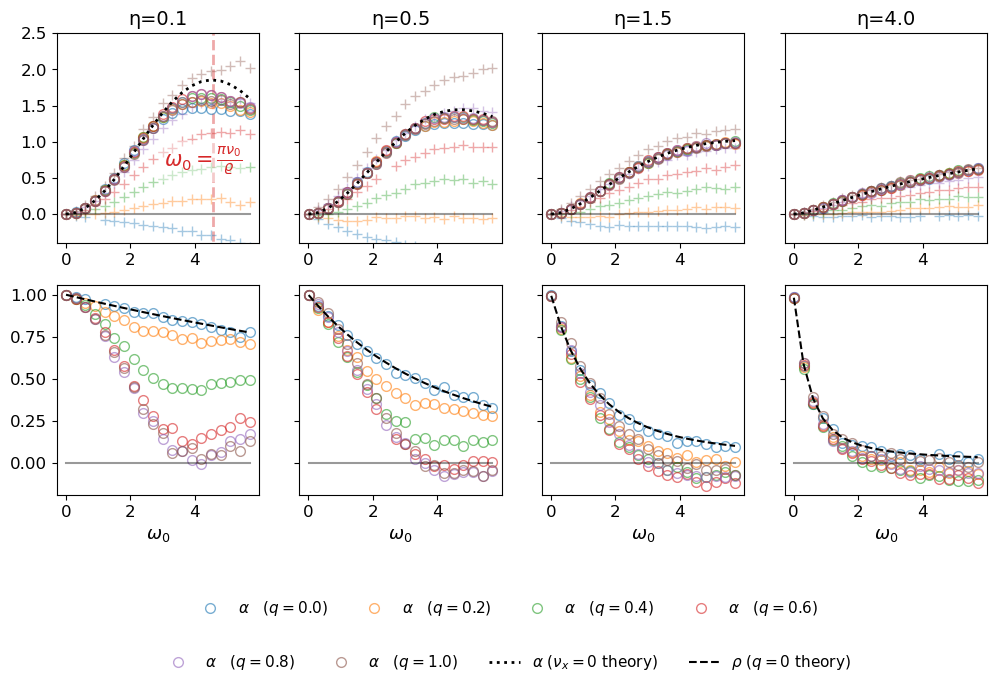

Python: None

In [30]:
include("model.jl")
include("formulas.jl")

fig, axs = subplots(figsize=(12, 6), ncols=length(ηrange),nrows=2, sharey="row")

axs[0,0].vlines(π/log(2)/sqrt(abs.(1-ηrange[1]^2)), ymin=-2, ymax=5, colors="C3", linestyles="--", lw=2,alpha=0.4)
axs[0,0].text(π/log(2)/sqrt(abs.(1-ηrange[1]^2))-0.3, 0.5, L"$\omega_0 = \frac{\pi \nu_0}{\varrho}$", color="C3", ha="center", va="bottom",
fontsize=15, bbox=Dict("facecolor"=>"white", "edgecolor"=>"none", "pad"=>3,"alpha"=>0.4))
for i in 1:length(ηrange)
    ax = axs[0,i-1]
    


    η = ηrange[i]
    jj= 0
    for j in 1:2:length(qrange)
        dfcell = data[(data.η .== η) .& (data.q .== qrange[j]), :]
        dfcell = dfcell[dfcell.cell .< unique(dfcell.cell)[end]-1,:]
        alphas = [-cov(df.ϕ, df.z0) / var(df.z0) for df in groupby(dfcell, :ω0)]
        αλs = [-cov(d.ϕ ./ d.τ, d.z0) / var(d.z0) * mean(d.τ) for d in groupby(dfcell, :ω0)]
        ax.plot(ω0range,alphas, "C$(jj)o", label="\$\\alpha \\quad({q}=$(qrange[j]))\$",fillstyle="none",alpha=0.6,markersize=7)
        ax.plot(ω0range,αλs, "C$(jj)+",alpha=0.4,fillstyle="none",markersize=7)
        jj = jj+1
    end


    # ax.plot(ω0range_,Ws[:,i,1], "C0-",label= L"$W_{1}$")
    # for k in 2:5
    #     ω0 = ω0range_[k]
    #     ax.plot(ω0range_, Ws[:,i,k], "-",alpha=0.6,label= "\$W_{$(k)}\$")
    # end
    #ax.plot([0],[0],"C0-",alpha=0.3,label= L"$W_{i},i>1$")


    ax.plot(ω0range, [1-ksho(log(2),η/2, ω0range[i])/ksho(0.0, η/2, ω0range[i]) for i in 1:length(ω0range)], "k:",label=L"$\alpha$ ($\nu_x =0$ theory)",lw=2)
    
    #
    
    ax.set_title("η=$(η)", fontsize=14)
    ax.set_ylim([-0.4,2.5])
    ax.tick_params(labelsize=12)
    ax.plot(ω0range,zeros(length(ω0range)),"k-",alpha=0.4)

    ax = axs[1,i-1]
    for j in 1:2:length(qrange)
        q = qrange[j]
        df = data[(data.η .== η) .& (data.q .== q),:]
        ρs = [cor(d.λ[2:end], d.λ[1:end-1]) for d in groupby(df, :ω0)]
        ax.plot(ω0range, ρs,"o",alpha=0.6,fillstyle="none",markersize=7)
    end
    df = data[(data.η .== η) .& (data.q .== qrange[end]),:]
    ρs_theory = [rho_SHO(η, ω0, 1, 1) for ω0 in ω0range]
    ax.plot(ω0range, ρs_theory,"k--",label=L"$\rho$ ($q=0$ theory)")
    ax.plot(ω0range,zeros(length(ω0range)),"k-",alpha=0.4)
    ax.set_xlabel(L"$\omega_0$", fontsize=13)
    ax.tick_params(labelsize=12)
end

# legends moved below the (now larger) panels, with entries split evenly across the two rows
handles0, labels0 = axs[0,length(ηrange)-1].get_legend_handles_labels()
handles1, labels1 = axs[1,length(ηrange)-1].get_legend_handles_labels()

all_handles = vcat(collect(handles0), collect(handles1))
all_labels = vcat(collect(labels0), collect(labels1))

n = length(all_handles)
nhalf = ceil(Int, n/2)

fig.legend(all_handles[1:nhalf], all_labels[1:nhalf], frameon=false, loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=nhalf, fontsize=11)
fig.legend(all_handles[nhalf+1:end], all_labels[nhalf+1:end], frameon=false, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=n-nhalf, fontsize=11)

savefig(joinpath(FIG_PATH, "fig7.pdf"), bbox_inches="tight", pad_inches=0.1, format="pdf")

sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


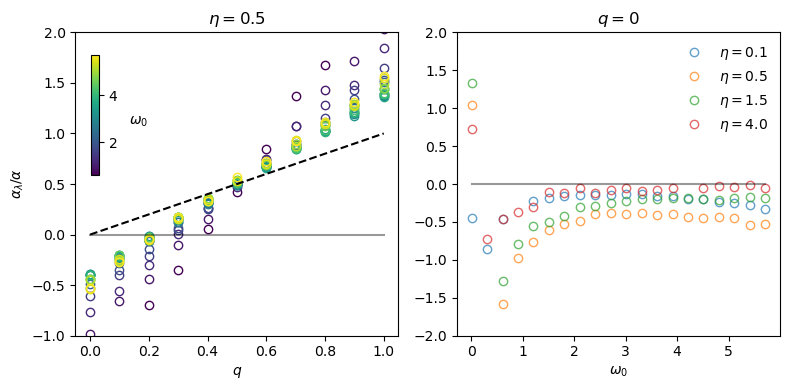

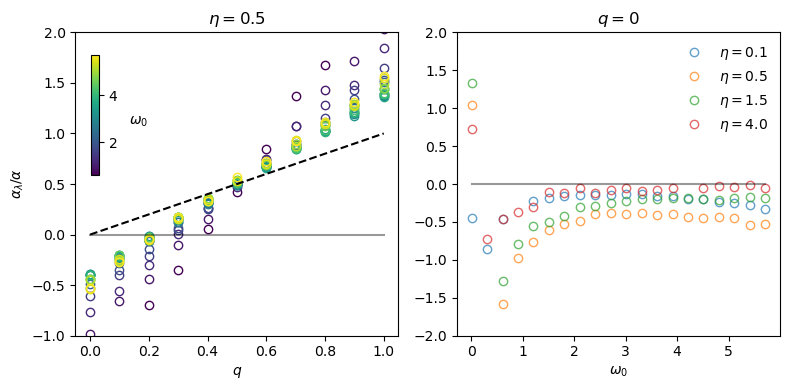

In [26]:
# Set up colormap for ω₀ values
ω0_selected = ω0range[3:1:end]
cmap = get_cmap("viridis")
norm_min, norm_max = minimum(ω0_selected), maximum(ω0_selected)

fig,axs = subplots(figsize=(8, 4),ncols=2)


ax = axs[0]

η =  ηrange[2]
ax.set_title("\$\\eta =$(η)\$")
for ω0 in ω0_selected
    df = data[(data.η .== η) .& (data.ω0 .== ω0), :]
    α = [-cov(d.ϕ, d.z0) / var(d.z0) for d in groupby(df, :q)]
    αλ = [-cov(d.ϕ ./ d.τ, d.z0) / var(d.z0) * mean(d.τ) for d in groupby(df, :q)]
    # Normalize ω0 value to [0,1] for colormap
    color_val = (ω0 - norm_min) / (norm_max - norm_min)
    color = cmap(color_val)
    ax.plot(qrange,αλ ./α,"o",color=color,fillstyle="none")
end
ax.set_ylim(-1,2)

ax.plot(qrange,zeros(length(qrange)),"k-",alpha=0.4)
ax.plot(qrange,qrange,"k--")
ax.set_ylabel(L"$\alpha_{\lambda}/\alpha$")

ax.set_xlabel(L"$q$")
norm = matplotlib.colors.Normalize(vmin=norm_min, vmax=norm_max)
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar_ax = fig.add_axes([0.12, 0.55, 0.01, 0.3])
fig.colorbar(sm, cax=cbar_ax)
cbar_ax.set_ylabel(L"$\omega_0$", rotation=0, labelpad=15)

ax = axs[1]
ax.set_title("\$q =0\$")
for η in ηrange
    df = data[(data.η .== η) .& (data.q.== 0.0), :]
    α = [-cov(d.ϕ, d.z0) / var(d.z0) for d in groupby(df, :ω0)]
    αλ = [-cov(d.ϕ ./ d.τ, d.z0) / var(d.z0) * mean(d.τ) for d in groupby(df, :ω0)]
    ax.plot(ω0range,αλ ./α,"o",alpha=0.7,label="\$\\eta=$η\$",fillstyle="none")
end


ax.plot(ω0range,zeros(length(ω0range)),"k-",alpha=0.4)
ax.set_ylim(-2,2)
ax.legend(frameon=false)
ax.set_xlabel(L"$\omega_0$")


tight_layout()
savefig(joinpath(FIG_PATH, "fig8.pdf"), bbox_inches="tight", pad_inches=0.1, format="pdf")
fig